# 필요 라이브러리

In [281]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import itertools
from joblib import Parallel, delayed
import statsmodels.api as sm

# 데이터 준비

In [282]:
start_date= "2001-01-01"
end_date= "2025-12-31"

In [283]:
ff = web.DataReader("F-F_Research_Data_Factors", "famafrench", start=start_date, end=end_date)[0].copy()

# 인덱스를 월말 날짜로
ff.index = pd.to_datetime(ff.index.astype(str)) + pd.offsets.MonthEnd(0)
# % -> 소수
ff = ff / 100.0


C:\Users\USER\AppData\Local\Temp\ipykernel_17672\3546956132.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff = web.DataReader("F-F_Research_Data_Factors", "famafrench", start=start_date, end=end_date)[0].copy()
C:\Users\USER\AppData\Local\Temp\ipykernel_17672\3546956132.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff = web.DataReader("F-F_Research_Data_Factors", "famafrench", start=start_date, end=end_date)[0].copy()


In [284]:
ff.isnull().sum()

Mkt-RF    0
SMB       0
HML       0
RF        0
dtype: int64

In [285]:
fr = ff[["Mkt-RF", "SMB", "HML"]].copy()   # excess returns
rf = ff["RF"].copy()                     # risk-free

In [286]:
ff

,Mkt-RF,SMB,HML,RF
Date,,,,
2001-01-31,0.0325,0.0641,-0.0505,0.0054
2001-02-28,-0.1003,-0.0065,0.1223,0.0038
2001-03-31,-0.0725,0.0026,0.0647,0.0042
2001-04-30,0.0793,0.0050,-0.0464,0.0039
2001-05-31,0.0068,0.0248,0.0338,0.0032
...,...,...,...,...
2025-08-31,0.0184,0.0387,0.0442,0.0038
2025-09-30,0.0339,-0.0185,-0.0105,0.0033
2025-10-31,0.0196,-0.0055,-0.0309,0.0037


In [287]:
# 애플, 10년물, 원유, 달러인덱스
tickers = ['AAPL','^TNX','CL=F','DX-Y.NYB']
raw_data=yf.download(tickers,start=start_date,end=end_date)

[*********************100%***********************]  4 of 4 completed


In [288]:
data=raw_data/100

In [289]:
data_month=data.resample('ME').last().dropna()#파마 프렌치 모형이랑 동일하게 월말로

In [290]:
data_month

Price          Close                                High                   \
Ticker          AAPL    CL=F DX-Y.NYB     ^TNX      AAPL    CL=F DX-Y.NYB   
Date                                                                        
2001-01-31  0.003240  0.2870   1.1052  0.05179  0.003371  0.2915   1.1118   
2001-02-28  0.002734  0.2742   1.1201  0.04908  0.002912  0.2820   1.1243   
2001-03-31  0.003306  0.2640   1.1737  0.04915  0.003404  0.2664   1.1763   
2001-04-30  0.003819  0.2846   1.1585  0.05338  0.004063  0.2899   1.1614   
2001-05-31  0.002989  0.2837   1.1907  0.05413  0.003032  0.2872   1.1929   
...              ...     ...      ...      ...       ...     ...      ...   
2025-08-31  2.316984  0.6401   0.9777  0.04227  2.329360  0.6455   0.9813   
2025-09-30  2.541456  0.6237   0.9777  0.04148  2.554331  0.6326   0.9805   
2025-10-31  2.698557  0.6098   0.9980  0.04101  2.767924  0.6138   0.9984   
2025-11-30  2.785893  0.5855   0.9946  0.04017  2.787392  0.5964   0.9982   
2025-12-31  2.728247  0.5795   0.9824  0.04130  2.738238  0.5847   0.9827   

Price                     Low                                Open          \
Ticker         ^TNX      AAPL    CL=F DX-Y.NYB     ^TNX      AAPL    CL=F   
Date                                                                        
2001-01-31  0.05196  0.003212  0.2825   1.1040  0.05167  0.003221  0.2900   
2001-02-28  0.04956  0.002715  0.2734   1.1170  0.04908  0.002903  0.2815   
2001-03-31  0.05121  0.003197  0.2596   1.1648  0.04878  0.003378  0.2645   
2001-04-30  0.05393  0.003726  0.2813   1.1547  0.05330  0.004000  0.2860   
2001-05-31  0.05481  0.002920  0.2755   1.1818  0.05409  0.002966  0.2805   
...             ...       ...     ...      ...      ...       ...     ...   
2025-08-31  0.04242  2.309298  0.6388   0.9769  0.04215  2.320677  0.6426   
2025-09-30  0.04152  2.526285  0.6203   0.9763  0.04106  2.543752  0.6314   
2025-10-31  0.04103  2.686480  0.5999   0.9942  0.04076  2.764631  0.6030   
2025-11-30  0.04036  2.757320  0.5827   0.9938  0.03990  2.770008  0.5858   
2025-12-31  0.04141  2.720255  0.5760   0.9794  0.04116  2.725550  0.5781   

Price                            Volume                         
Ticker     DX-Y.NYB     ^TNX       AAPL     CL=F DX-Y.NYB ^TNX  
Date                                                            
2001-01-31   1.1100  0.05179  7307048.0   856.59      0.0  0.0  
2001-02-28   1.1224  0.04924  5082336.0   823.64      0.0  0.0  
2001-03-31   1.1657  0.05007  4003496.0   639.47      0.0  0.0  
2001-04-30   1.1567  0.05330  4947768.0   402.23      0.0  0.0  
2001-05-31   1.1830  0.05481  4428928.0  1016.94      0.0  0.0  
...             ...      ...        ...      ...      ...  ...  
2025-08-31   0.9787  0.04228   394184.0     0.00      0.0  0.0  
2025-09-30   0.9791  0.04133   377043.0  2716.49      0.0  0.0  
2025-10-31   0.9949  0.04101   861671.0  2785.98      0.0  0.0  
2025-11-30   0.9957  0.03990   201356.0  1537.58      0.0  0.0  
2025-12-31   0.9801  0.04141   221396.0  1438.02      0.0  0.0  

[300 rows x 20 columns]

In [291]:
returns=pd.DataFrame()
returns['Oil']=data_month['Close']['CL=F'].pct_change()
returns['USD']=data_month['Close']['DX-Y.NYB'].pct_change()
returns['Yield']=data_month['Close']['^TNX'].diff()
returns.dropna(inplace=True)

## 비교 분석

In [292]:
def calculate_factor_risk_contribution(target, factors):
    X=sm.add_constant(factors)
    model=sm.OLS(target,X).fit()
    betas=model.params.drop('const')
    variance=np.var(target,ddof=1)
    contribution={}
    explained=0
    for i in factors.columns:
        component=betas[i]*factors[i]
        cov=np.cov(target,component)[0,1]
        contributions=(cov/variance)*100
        contribution[i]=contributions
        explained+=cov
    unexplainables=((variance - explained) / variance) * 100
    contribution['unexplainable']=unexplainables
    return contribution

In [293]:
target=data_month['Close']['AAPL'].pct_change()-rf
target=target.dropna()

In [294]:
fund=calculate_factor_risk_contribution(target,ff[1:])
macro_factors=pd.concat([returns,ff["Mkt-RF"]],axis=1).dropna()
macro=calculate_factor_risk_contribution(target,macro_factors)

In [295]:
df_risk=pd.DataFrame({
    "fundamental":pd.Series(fund),
    "Macro Model":pd.Series(macro)
}).fillna(0)

In [296]:
df_risk#시장요인이 있을 땐 둘 다 시장요인이 압도적임

,fundamental,Macro Model
HML,2.610317,0.000000
Mkt-RF,29.957145,32.082943
Oil,0.000000,1.314398
RF,-0.035757,0.000000
SMB,0.504868,0.000000
USD,0.000000,-1.294131
Yield,0.000000,-0.515034
unexplainable,66.963427,68.411823


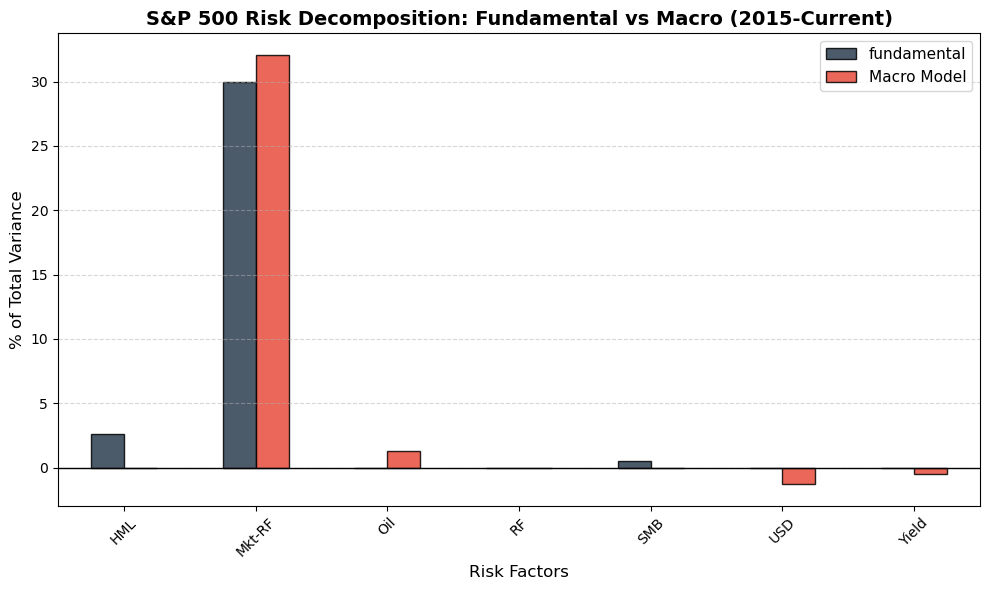

In [297]:
df_factor_only = df_risk.drop('unexplainable') # 순수 팩터 비교를 위해 고유 위험 제외

fig, ax = plt.subplots(figsize=(10, 6))
df_factor_only.plot(kind='bar', ax=ax, color=['#2c3e50', '#e74c3c'], alpha=0.85, edgecolor='black')

plt.title('S&P 500 Risk Decomposition: Fundamental vs Macro (2015-Current)', fontsize=14, fontweight='bold')
plt.ylabel('% of Total Variance', fontsize=12)
plt.xlabel('Risk Factors', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [298]:
fundamental=ff[["Mkt-RF","SMB", "HML"]]
fund=calculate_factor_risk_contribution(target,fundamental[1:])
# macro_factors=pd.concat([returns,ff["Mkt-RF"]],axis=1).dropna()
macro=calculate_factor_risk_contribution(target,returns)

In [299]:
df_risk_nomkt=pd.DataFrame({
    "fundamental":pd.Series(fund),
    "Macro Model":pd.Series(macro)
}).fillna(0)

In [300]:
df_risk_nomkt

,fundamental,Macro Model
HML,2.607666,0.000000
Mkt-RF,29.917509,0.000000
Oil,0.000000,3.380834
SMB,0.475781,0.000000
USD,0.000000,0.584824
Yield,0.000000,0.821854
unexplainable,66.999044,95.212489


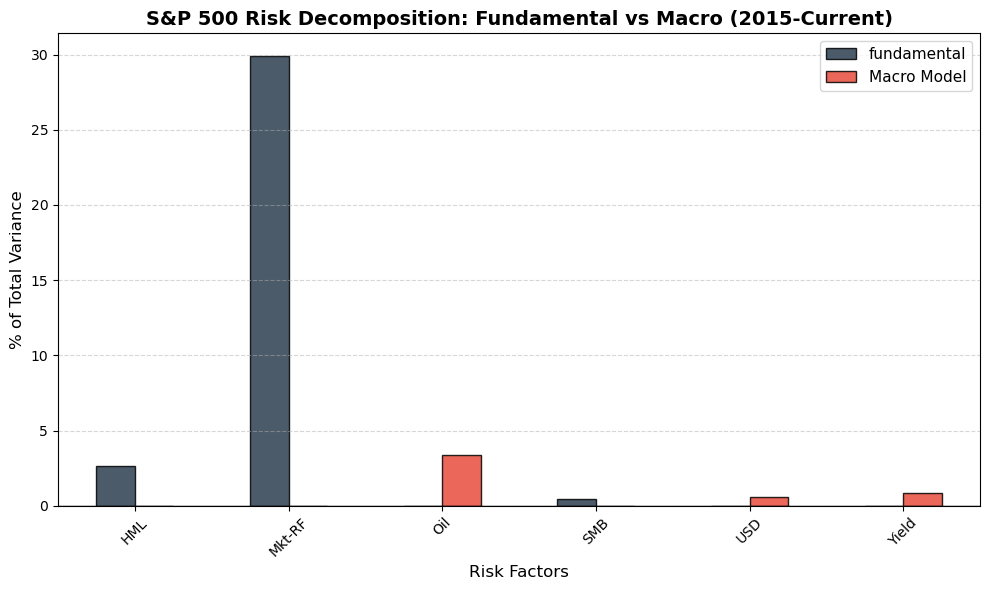

In [301]:
df_factor_only_nomkt = df_risk_nomkt.drop('unexplainable') # 순수 팩터 비교를 위해 고유 위험 제외

fig, ax = plt.subplots(figsize=(10, 6))
df_factor_only_nomkt.plot(kind='bar', ax=ax, color=['#2c3e50', '#e74c3c'], alpha=0.85, edgecolor='black')

plt.title('S&P 500 Risk Decomposition: Fundamental vs Macro (2015-Current)', fontsize=14, fontweight='bold')
plt.ylabel('% of Total Variance', fontsize=12)
plt.xlabel('Risk Factors', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [302]:
fundamental=ff[["Mkt-RF","SMB", "HML"]]
fund=calculate_factor_risk_contribution(target,fundamental[1:])
# macro_factors=pd.concat([returns,ff["Mkt-RF"]],axis=1).dropna()
macro=calculate_factor_risk_contribution(target,returns)

In [303]:
df_risk=pd.DataFrame({
    "fundamental":pd.Series(fund),
    "Macro Model":pd.Series(macro)
}).fillna(0)

In [304]:
df_risk

,fundamental,Macro Model
HML,2.607666,0.000000
Mkt-RF,29.917509,0.000000
Oil,0.000000,3.380834
SMB,0.475781,0.000000
USD,0.000000,0.584824
Yield,0.000000,0.821854
unexplainable,66.999044,95.212489


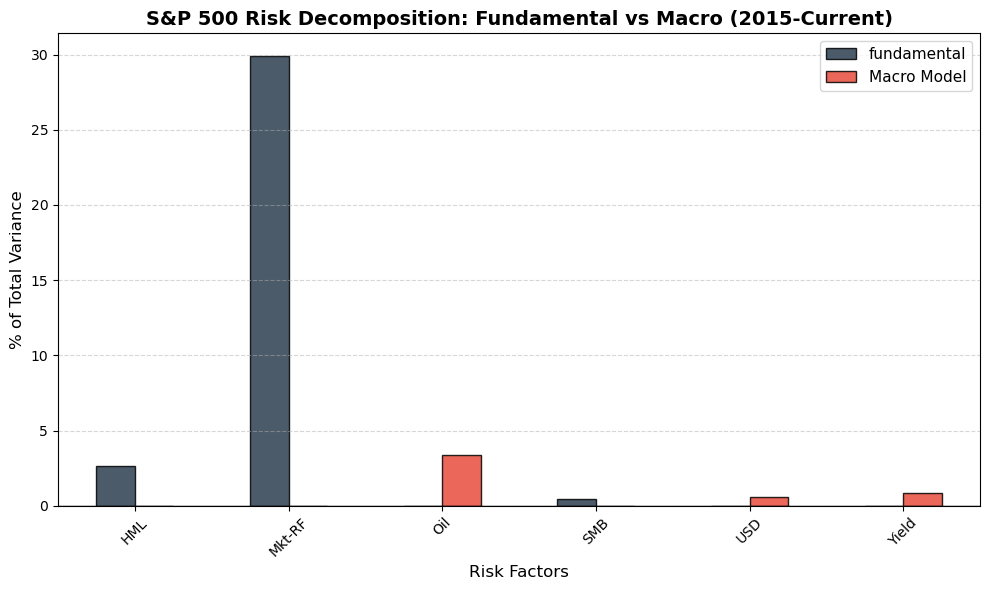

In [305]:
df_factor_only_nomkt = df_risk_nomkt.drop('unexplainable') # 순수 팩터 비교를 위해 고유 위험 제외

fig, ax = plt.subplots(figsize=(10, 6))
df_factor_only_nomkt.plot(kind='bar', ax=ax, color=['#2c3e50', '#e74c3c'], alpha=0.85, edgecolor='black')

plt.title('S&P 500 Risk Decomposition: Fundamental vs Macro (2015-Current)', fontsize=14, fontweight='bold')
plt.ylabel('% of Total Variance', fontsize=12)
plt.xlabel('Risk Factors', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# 위 결과를 이용해서 회귀식 만들기

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.323
Method:                 Least Squares   F-statistic:                     48.43
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           1.76e-25
Time:                        00:13:41   Log-Likelihood:                 335.05
No. Observations:                 299   AIC:                            -662.1
Df Residuals:                     295   BIC:                            -647.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0184      0.005      3.955      0.0

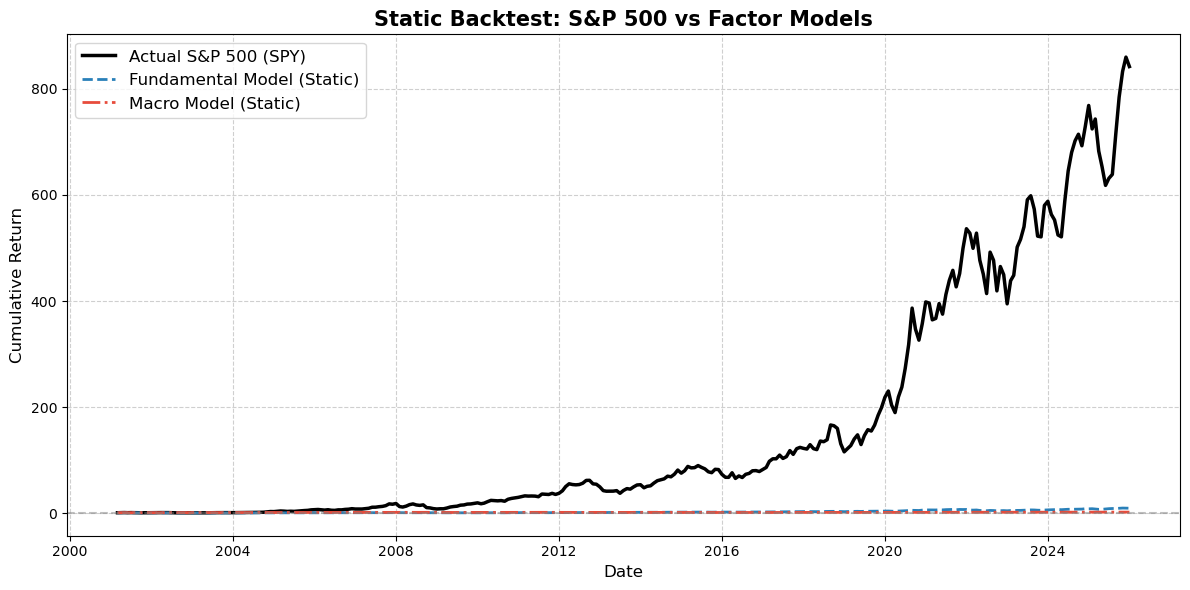

In [306]:
def get_static_betas(target, factors):
    X = sm.add_constant(factors)
    model = sm.OLS(target, X).fit()
    betas = model.params.drop('const')
    print(model.summary())
    return betas
fundamental_factors = ff[["Mkt-RF", "SMB", "HML"]]
common_idx = target.index.intersection(fundamental_factors.index).intersection(returns.index)
target_align = target.loc[common_idx]
fund_align = fundamental_factors.loc[common_idx]
macro_align = returns.loc[common_idx]
rf_align = rf.loc[common_idx]
beta_fund = get_static_betas(target_align, fund_align)
beta_macro = get_static_betas(target_align, macro_align)
print("--- Fundamental Model Betas ---")
print(beta_fund)
print("\n--- Macro Model Betas ---")
print(beta_macro)
model_fund_ret = (fund_align * beta_fund).sum(axis=1) + rf_align
model_macro_ret = (macro_align * beta_macro).sum(axis=1) + rf_align
actual_spy_ret = target_align + rf_align
cum_spy = (1 + actual_spy_ret).cumprod()
cum_fund = (1 + model_fund_ret).cumprod()
cum_macro = (1 + model_macro_ret).cumprod()



#백테스트 결과 시각화
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_spy.index, cum_spy, label='Actual S&P 500 (SPY)', color='black', linewidth=2.5)
ax.plot(cum_fund.index, cum_fund, label='Fundamental Model (Static)', color='#2980b9', linestyle='--', linewidth=2)
ax.plot(cum_macro.index, cum_macro, label='Macro Model (Static)', color='#e74c3c', linestyle='-.', linewidth=2)
ax.set_title('Static Backtest: S&P 500 vs Factor Models', fontsize=15, fontweight='bold')
ax.set_ylabel('Cumulative Return', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     9.438
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           0.000106
Time:                        00:13:41   Log-Likelihood:                 284.42
No. Observations:                 299   AIC:                            -562.8
Df Residuals:                     296   BIC:                            -551.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0258      0.005      4.744      0.0

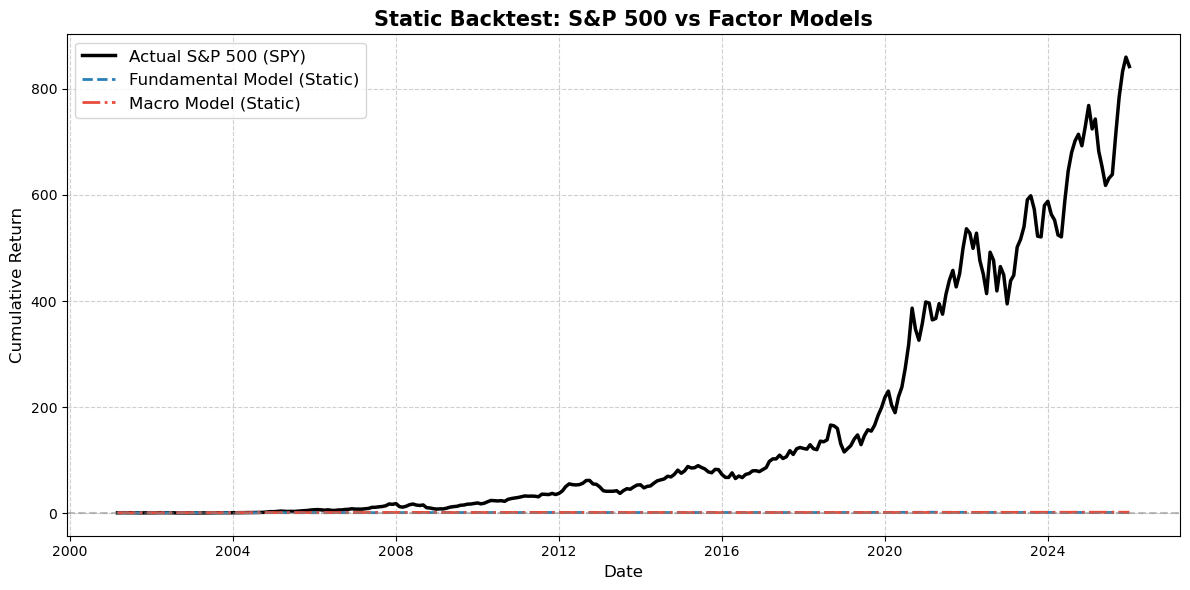

In [307]:
fundamental_factors = ff[[ "SMB", "HML"]]
common_idx = target.index.intersection(fundamental_factors.index).intersection(returns.index)
fund_align = fundamental_factors.loc[common_idx]
beta_fund = get_static_betas(target_align, fund_align)
beta_macro = get_static_betas(target_align, macro_align)
print("--- Fundamental Model Betas ---")
print(beta_fund)
print("\n--- Macro Model Betas ---")
print(beta_macro)
model_fund_ret = (fund_align * beta_fund).sum(axis=1) + rf_align
cum_fund = (1 + model_fund_ret).cumprod()



fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_spy.index, cum_spy, label='Actual S&P 500 (SPY)', color='black', linewidth=2.5)
ax.plot(cum_fund.index, cum_fund, label='Fundamental Model (Static)', color='#2980b9', linestyle='--', linewidth=2)
ax.plot(cum_macro.index, cum_macro, label='Macro Model (Static)', color='#e74c3c', linestyle='-.', linewidth=2)
ax.set_title('Static Backtest: S&P 500 vs Factor Models', fontsize=15, fontweight='bold')
ax.set_ylabel('Cumulative Return', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     72.69
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           2.08e-26
Time:                        00:13:42   Log-Likelihood:                 334.91
No. Observations:                 299   AIC:                            -663.8
Df Residuals:                     296   BIC:                            -652.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0184      0.005      3.954      0.0

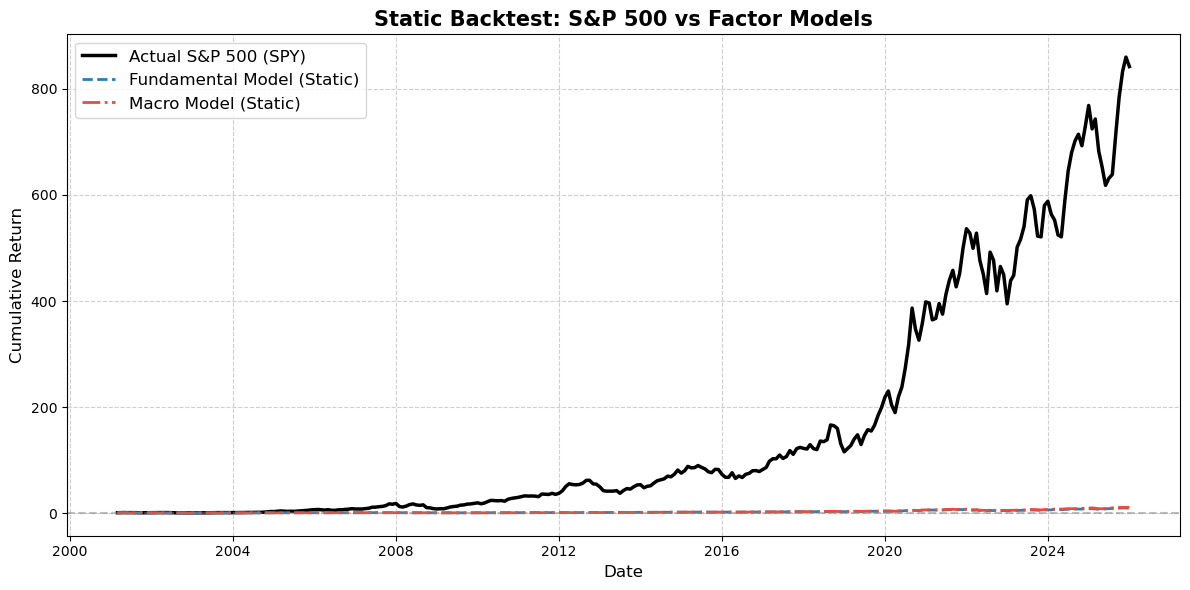

In [308]:
# fundamental_factors = ff[["Mkt-RF", "SMB", "HML"]]
fundamental_factors = ff[["Mkt-RF", "HML"]]
common_idx = target.index.intersection(fundamental_factors.index).intersection(returns.index)
fund_align = fundamental_factors.loc[common_idx]
# macro_align = pd.concat([returns.loc[common_idx], ff["Mkt-RF"].loc[common_idx]], axis=1)
macro_align = pd.concat([returns["USD"].loc[common_idx], ff[["Mkt-RF", "HML"]].loc[common_idx]], axis=1)
beta_fund = get_static_betas(target_align, fund_align)
beta_macro = get_static_betas(target_align, macro_align)
print("--- Fundamental Model Betas ---")
print(beta_fund)
print("\n--- Macro Model Betas ---")
print(beta_macro)
model_fund_ret = (fund_align * beta_fund).sum(axis=1) + rf_align
model_macro_ret = (macro_align * beta_macro).sum(axis=1) + rf_align
cum_fund = (1 + model_fund_ret).cumprod()
cum_macro = (1 + model_macro_ret).cumprod()



fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_spy.index, cum_spy, label='Actual S&P 500 (SPY)', color='black', linewidth=2.5)
ax.plot(cum_fund.index, cum_fund, label='Fundamental Model (Static)', color='#2980b9', linestyle='--', linewidth=2)
ax.plot(cum_macro.index, cum_macro, label='Macro Model (Static)', color='#e74c3c', linestyle='-.', linewidth=2)
ax.set_title('Static Backtest: S&P 500 vs Factor Models', fontsize=15, fontweight='bold')
ax.set_ylabel('Cumulative Return', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Economic Factor로 rollover해보면서 설명력 봐보기

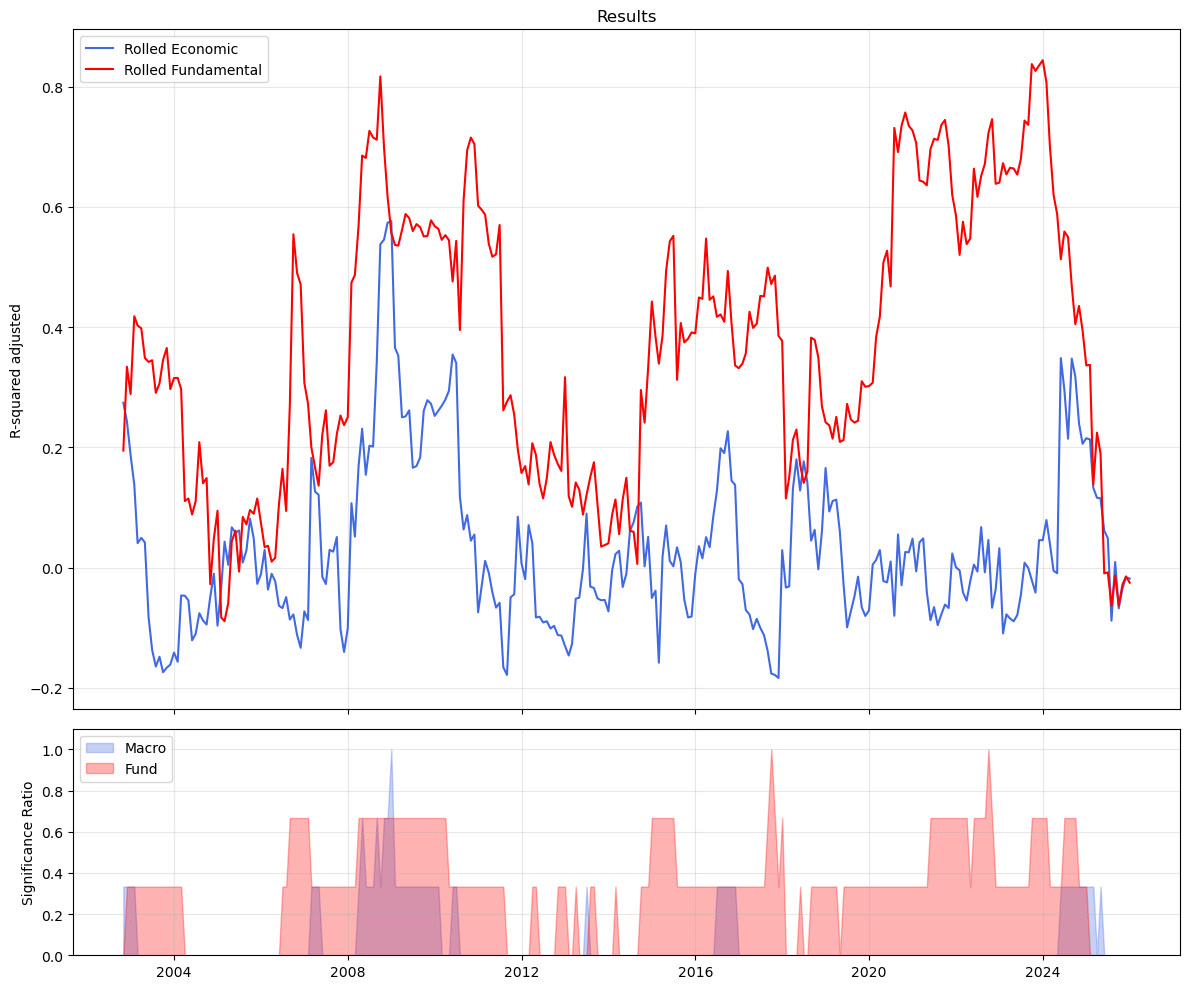

In [ ]:
window_size=20
common_idx = target.index.intersection(fundamental.index).intersection(returns.index)
fund_adj = fundamental.loc[common_idx]
macro_adj = returns.loc[common_idx]
target_adj = target.loc[common_idx]
result_r2=[]
result_r2f=[]
result_r2f_noroll=[]
valid_m=[]
valid_f=[]
valid_fn=[]
def get_rsquared(target, factors):
    X = sm.add_constant(factors.values)
    model = sm.OLS(target.values, X).fit()
    p_values = model.pvalues[1:]
    valid=np.mean(p_values<0.05)
    return model.rsquared_adj,valid
for i in range(len(target)-window_size+1):
    start_index=i
    end_index=i+window_size
    target_rolled=target_adj.iloc[start_index:end_index]
    target_notrolled=target_adj.iloc[:end_index]
    fundamental_input=fund_adj.iloc[start_index:end_index]
    fundamental_no_roll=fund_adj[:end_index]
    macro_input=macro_adj[start_index:end_index]
    r2,vm=get_rsquared(target_rolled,macro_input)
    r2f,vf=get_rsquared(target_rolled,fundamental_input)
    r2f_no,vn=get_rsquared(target_notrolled,fundamental_no_roll)
    result_r2.append(r2)
    result_r2f.append(r2f)
    result_r2f_noroll.append(r2f_no)
    valid_m.append(vm)
    valid_f.append(vf)
    valid_fn.append(vn)
dates = target.index[window_size - 1:] 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
# 상단 그래프: R-squared
ax1.plot(dates, result_r2, label='Rolled Economic', color='royalblue')
ax1.plot(dates, result_r2f, label='Rolled Fundamental', color='red')
# ax1.axhline(y=0.323, color='black', linestyle=':', label='Benchmark 0.323')
ax1.set_ylabel('R-squared adjusted')
ax1.set_title('Results')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 하단 그래프: 유의성 비율 (0~1 사이 값)
# 1에 가까울수록 모델 내 대부분의 변수가 통계적으로 유의함
ax2.fill_between(dates, valid_m, color='royalblue', alpha=0.3, label='Macro')
ax2.fill_between(dates, valid_f, color='red', alpha=0.3, label='Fund')
# ax2.fill_between(dates, valid_fn, color='green', alpha=0.3, label='Fund Significance')
ax2.set_ylabel('Significance Ratio')
ax2.set_ylim(0, 1.1)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# switching model 테스트 해보기

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.optimize as sco 
import yfinance as yf

In [ ]:
start_date = "2000-01-01"
end_date = "2025-12-31" 
tickers = ['AAPL', 'MSFT', 'AMZN']
raw_data_test = yf.download(tickers, start=start_date, end=end_date)
data_month_test = raw_data_test['Close'].resample('ME').last().dropna()
portfolio = data_month_test.pct_change().dropna()
portfolio.columns = ['AAPL', 'AMZN', 'MSFT'] 

[*********************100%***********************]  3 of 3 completed


In [ ]:
def get_optimal_weights(mu, cov_matrix, target_return=0.0001):
    num_assets = len(mu)
    def objective_function(weights):
        return weights.T @ cov_matrix @ weights
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0},{'type': 'ineq', 'fun': lambda x: (x.T @ mu) -target_return})
    bounds = tuple((0.0, 1.0) for _ in range(num_assets))
    init_guess = np.array(num_assets * [1. / num_assets])   
    result = sco.minimize(objective_function, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x
def get_rsquared(target_series, factors):
    X = sm.add_constant(factors.values)
    model = sm.OLS(target_series.values, X).fit()
    p_values = model.pvalues[1:]
    valid = np.mean(p_values < 0.05)
    return model.rsquared_adj, valid


In [ ]:
window_size = 13
target = portfolio.copy()
target.index = pd.to_datetime(target.index.astype(str)).to_period('M')
fundamental.index = pd.to_datetime(fundamental.index.astype(str)).to_period('M')
returns.index = pd.to_datetime(returns.index.astype(str)).to_period('M')
common_idx = target.index.intersection(fundamental.index).intersection(returns.index)
fund_adj = fundamental.loc[common_idx]
macro_adj = returns.loc[common_idx]
target_adj = target.loc[common_idx]
target_adj.index = target_adj.index.to_timestamp('M')
fund_adj.index = fund_adj.index.to_timestamp('M')
macro_adj.index = macro_adj.index.to_timestamp('M')

In [ ]:
weights_method1_dynamic = []
weights_method2_static = []

for i in range(len(target_adj) - window_size):
    start_index = i
    end_index = i + window_size
    target_rolled = target_adj.iloc[start_index:end_index]
    target_notrolled = target_adj.iloc[:end_index]
    fundamental_input = fund_adj.iloc[start_index:end_index]
    fundamental_no_roll = fund_adj.iloc[:end_index]
    macro_input = macro_adj.iloc[start_index:end_index]
    mu_m1 = []
    mu_m2 = []
    for col in target_adj.columns:
        y_rolled_col = target_rolled[col]
        y_notrolled_col = target_notrolled[col]
        r2_m, _ = get_rsquared(y_rolled_col, macro_input)#end-1까지로 평가함
        r2_f, _ = get_rsquared(y_rolled_col, fundamental_input)       
        if r2_m > r2_f:
            model = sm.OLS(y_rolled_col.values, sm.add_constant(macro_input.values)).fit()
            new_row = macro_adj.iloc[end_index-1].values#end-1 시점의 정보로 예측함 end를 예측함
            next_factor = np.insert(np.atleast_1d(new_row), 0, 1.0)#상수항 추가
        else:
            model = sm.OLS(y_rolled_col.values, sm.add_constant(fundamental_input.values)).fit()
            new_row = fund_adj.iloc[end_index-1].values
            next_factor = np.insert(np.atleast_1d(new_row), 0, 1.0) # 상수항 추가
        pred_1 = model.predict(next_factor)[0]
        mu_m1.append(pred_1)
        model_no = sm.OLS(y_notrolled_col.values, sm.add_constant(fundamental_no_roll.values)).fit()
        new_row_no = fund_adj.iloc[end_index-1].values
        next_factor_no = np.insert(np.atleast_1d(new_row_no), 0, 1.0)
        pred_2 = model_no.predict(next_factor_no)[0]
        mu_m2.append(pred_2)
    cov_matrix = target_rolled.cov().values    
    w_m1 = get_optimal_weights(np.array(mu_m1), cov_matrix)
    w_m2 = get_optimal_weights(np.array(mu_m2), cov_matrix)    
    weights_method1_dynamic.append(w_m1)
    weights_method2_static.append(w_m2)

In [ ]:
weights_method1_dynamic = []
weights_method2_static = []

for i in range(len(target_adj) - window_size):
    start_index = i
    end_index = i + window_size
    
    # 데이터 슬라이싱 (윈도우 크기 20)
    target_rolled = target_adj.iloc[start_index:end_index]
    target_notrolled = target_adj.iloc[:end_index]
    fundamental_input = fund_adj.iloc[start_index:end_index]
    fundamental_no_roll = fund_adj.iloc[:end_index]
    macro_input = macro_adj.iloc[start_index:end_index]
    
    mu_m1 = []
    mu_m2 = []
    
    for col in target_adj.columns:
        # ==========================================================
        # 1. 훈련 데이터 셋팅 (공정한 비교를 위해 Y 길이를 19개로 통일)
        # ==========================================================
        # Y (타겟 수익률): 예측 대상이므로 t=1 부터 t=19 까지 사용
        Y_train = target_rolled[col].iloc[1:]
        
        # X (거시 팩터): 지연(Lagged) 적용. 과거 t=0 부터 t=18 까지 사용
        X_macro_train = macro_input.iloc[:-1]
        
        # X (파마프렌치): 동행(Contemporaneous) 적용. Y와 똑같이 t=1 부터 t=19 까지 사용
        X_fund_train = fundamental_input.iloc[1:]
        
        # 설명력(R-squared) 비교 
        r2_m, _ = get_rsquared(Y_train, X_macro_train)
        r2_f, _ = get_rsquared(Y_train, X_fund_train)       
        
        # ==========================================================
        # 2. 방법 1: Dynamic 기대 수익률 산출
        # ==========================================================
        if r2_m > r2_f:
            # 🟢 [거시경제 모델] 승리: 지연 회귀로 다음 달 직접 예측
            model = sm.OLS(Y_train.values, sm.add_constant(X_macro_train.values)).fit()
            
            # 예측 인풋: 우리가 볼 수 있는 가장 최신(마지막 달) 거시 데이터 투입
            latest_macro = macro_input.iloc[-1].values 
            next_factor = np.insert(np.atleast_1d(latest_macro), 0, 1.0) # 상수항 추가
            
            pred_1 = model.predict(next_factor)[0]
            
        else:
            # 🔵 [파마-프렌치 모델] 승리: 동행 회귀로 베타(체질) 구하고 평균 곱하기
            model = sm.OLS(Y_train.values, sm.add_constant(X_fund_train.values)).fit()
            betas = model.params # [알파, 베타1, 베타2, 베타3]
            
            # 팩터 기대수익률: 과거 20개월간 파마-프렌치 팩터들의 장기 평균치
            expected_ff_returns = fundamental_input.mean().values
            
            # 미래 수익률 = 알파 + (베타1 * 기대수익1) + (베타2 * 기대수익2) ...
            pred_1 = betas[0] + np.dot(betas[1:], expected_ff_returns)
            
        mu_m1.append(pred_1)       
        
        # ==========================================================
        # 3. 방법 2: Static 기대 수익률 산출 (파마-프렌치 누적 전체 사용)
        # ==========================================================
        Y_train_no = target_notrolled[col].iloc[1:]
        X_fund_train_no = fundamental_no_roll.iloc[1:]
        
        model_no = sm.OLS(Y_train_no.values, sm.add_constant(X_fund_train_no.values)).fit()
        betas_no = model_no.params
        
        # 누적 전체 기간에 대한 파마-프렌치 팩터들의 장기 평균치
        expected_ff_returns_no = fundamental_no_roll.mean().values
        pred_2 = betas_no[0] + np.dot(betas_no[1:], expected_ff_returns_no)
        
        mu_m2.append(pred_2)
        
    # ==========================================================
    # 4. 공분산 행렬 계산 및 MVO(포트폴리오 비중) 최적화
    # ==========================================================
    # 공분산은 과거 20개월의 데이터 전체(길이 20)를 사용하여 가장 안정적으로 뽑습니다.
    cov_matrix = target_rolled.cov().values    
    
    w_m1 = get_optimal_weights(np.array(mu_m1), cov_matrix)
    w_m2 = get_optimal_weights(np.array(mu_m2), cov_matrix)    
    
    weights_method1_dynamic.append(w_m1)
    weights_method2_static.append(w_m2)

=== 포트폴리오 성과 비교 ===
                    Method 1  Method 2
Mean Return         0.016621  0.016969
Variance            0.004323  0.003413
Sharpe Ratio        0.252795  0.290464
Max Drawdown (MDD) -0.675766 -0.562685


ValueError: x and y must have same first dimension, but have shapes (286,) and (283,)

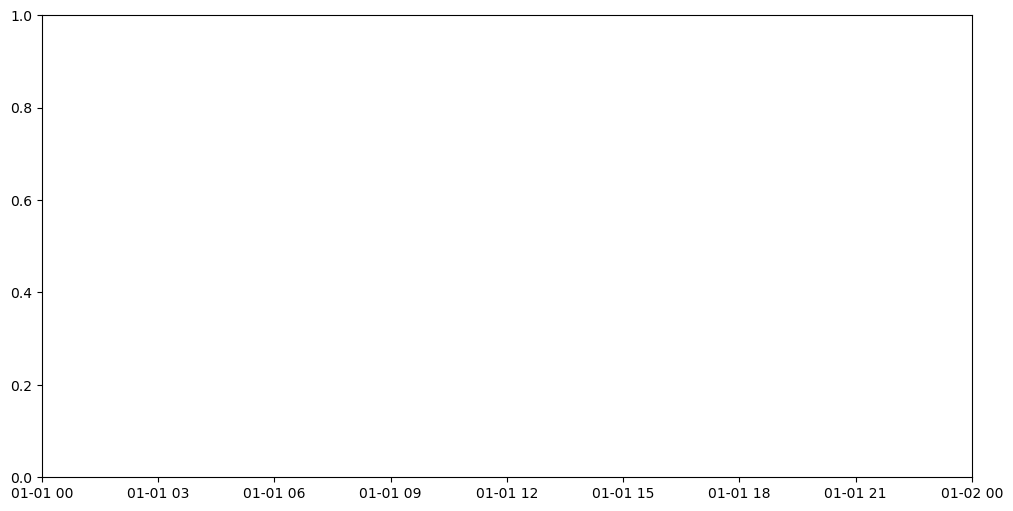

In [ ]:
#----------------------------
#       수익률 시각화하기
#----------------------------
port_returns_m1 = []
port_returns_m2 = []

for i in range(len(weights_method1_dynamic)):
    actual_returns = target_adj.iloc[window_size + i].values
    
    ret_m1 = np.dot(weights_method1_dynamic[i], actual_returns)
    ret_m2 = np.dot(weights_method2_static[i], actual_returns)
    
    port_returns_m1.append(ret_m1)
    port_returns_m2.append(ret_m2)

port_returns_m1 = np.array(port_returns_m1)
port_returns_m2 = np.array(port_returns_m2)

def calculate_metrics(returns, risk_free_rate=0.0):
    mean_ret = np.mean(returns)
    var_ret = np.var(returns)
    std_ret = np.std(returns)
    
    sharpe_ratio = (mean_ret - risk_free_rate) / std_ret if std_ret != 0 else 0
    
    cum_returns = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cum_returns)
    drawdowns = (cum_returns - running_max) / running_max
    mdd = np.min(drawdowns)
    
    return mean_ret, var_ret, sharpe_ratio, mdd

mean1, var1, sharpe1, mdd1 = calculate_metrics(port_returns_m1)
mean2, var2, sharpe2, mdd2 = calculate_metrics(port_returns_m2)

metrics_df = pd.DataFrame({
    'Method 1': [mean1, var1, sharpe1, mdd1],
    'Method 2': [mean2, var2, sharpe2, mdd2]
}, index=['Mean Return', 'Variance', 'Sharpe Ratio', 'Max Drawdown (MDD)'])

print("=== 포트폴리오 성과 비교 ===")
print(metrics_df)

# 누적 수익률 시각화
plt.figure(figsize=(12, 6))
dates_eval = target_adj.index[window_size:]

plt.plot(dates_eval, np.cumprod(1 + port_returns_m1) - 1, label='Method 1', color='royalblue', linewidth=1.5)
plt.plot(dates_eval, np.cumprod(1 + port_returns_m2) - 1, label='Method 2', color='crimson', linewidth=1.5)

plt.title('Cumulative Portfolio Returns Comparison', fontsize=14)
plt.ylabel('Cumulative Return', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# 요인 개수 비교

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
import pandas_datareader.data as web
from scipy.linalg import inv

# ==========================================
# 1. 데이터 수집 및 정제 (BMA용 매크로 데이터 제거)
# ==========================================
START, END = "2005-01-01", "2024-12-31"

def get_complete_data():
    print("📡 데이터를 수집 중입니다...")
    ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", START, END)[0] / 100.0
    mom = web.DataReader("F-F_Momentum_Factor", "famafrench", START, END)[0] / 100.0
    
    F = pd.concat([ff5[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]], mom], axis=1).dropna()
    F.columns = ["Mkt", "SMB", "HML", "RMW", "CMA", "Mom"]
    RF = ff5["RF"]
    
    for df in [F, RF]: df.index = df.index.to_timestamp().to_period('M')
    common = F.index.intersection(RF.index)
    
    return [df.loc[common].to_timestamp(how='end').resample('ME').last().ffill().dropna() for df in [F, RF]]

F, RF = get_complete_data()

# ==========================================
# 2. 핵심 수학 엔진 (Static, AR1)
# ==========================================
def mv_weights(mu, cov, gamma=5.0):
    w = (1.0 / gamma) * inv(cov + np.eye(len(cov))*1e-6) @ mu
    w = np.maximum(w, 0.0) # 공매도 금지(Long-only) 조건
    return w / w.sum() if w.sum() > 1e-12 else np.ones_like(w)/len(w)

def get_static_forecast(train_f):
    """원래 요인 모형 (Static): 과거 평균 수익률을 미래 기대 수익률로 사용"""
    return train_f.mean().values

def get_ar1_forecast(train_f):
    """AR(1) 모형: 직전 과거 수익률의 추세를 반영하여 다음 기 수익률 예측"""
    return np.array([AutoReg(train_f[c].values, 1, trend='c').fit().forecast(1)[0] for c in train_f.columns])

def perf_stats(r, name):
    r = r.dropna()
    ann_ret = (1 + r).prod()**(12/len(r)) - 1
    ann_vol = r.std() * np.sqrt(12)
    sr = ann_ret / ann_vol
    mdd = ((1+r).cumprod() / (1+r).cumprod().cummax() - 1).min()
    return pd.Series([ann_ret, ann_vol, sr, mdd], index=['Return', 'Vol', 'Sharpe', 'MDD'], name=name)

# ==========================================
# 3. 백테스트 실행 (Static vs AR1)
# ==========================================
WINDOW = 60
dates = F.index
subsets = {
    "FF3": ["Mkt", "SMB", "HML"],
    "FF4": ["Mkt", "SMB", "HML", "Mom"],
    "FF5": ["Mkt", "SMB", "HML", "RMW", "CMA"],
    "FF6": ["Mkt", "SMB", "HML", "RMW", "CMA", "Mom"]
}

rets_dict = {"Market": []}
for k in subsets.keys():
    rets_dict[f"Static_{k}"] = []
    rets_dict[f"AR1_{k}"] = []

print("📈 [Static vs AR1] 백테스트 시작...")

for t in range(WINDOW, len(dates)):
    rf_next = float(RF.iloc[t])
    rets_dict["Market"].append(F["Mkt"].iloc[t] + rf_next)
    
    for name, cols in subsets.items():
        t_f = F[cols].iloc[t-WINDOW:t]
        f_next = F[cols].iloc[t].values
        cov = t_f.cov().values
        
        # 1. Static (단순 과거 평균)
        mu_static = get_static_forecast(t_f)
        rets_dict[f"Static_{name}"].append(rf_next + np.dot(mv_weights(mu_static, cov), f_next))
        
        # 2. AR1 (자기회귀 예측)
        mu_ar = get_ar1_forecast(t_f)
        rets_dict[f"AR1_{name}"].append(rf_next + np.dot(mv_weights(mu_ar, cov), f_next))

# ==========================================
# 4. 결과 출력
# ==========================================
res_df = pd.DataFrame(rets_dict, index=dates[WINDOW:])
summary = pd.concat([perf_stats(res_df[c], c) for c in res_df.columns], axis=1).T

print("\n=== 🏆 [Static vs AR1] 최종 성과 비교 ===")
print(summary.sort_values("Sharpe", ascending=False))

📡 데이터를 수집 중입니다...


C:\Users\USER\AppData\Local\Temp\ipykernel_14964\3167162748.py:16: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", START, END)[0] / 100.0
C:\Users\USER\AppData\Local\Temp\ipykernel_14964\3167162748.py:16: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", START, END)[0] / 100.0
C:\Users\USER\AppData\Local\Temp\ipykernel_14964\3167162748.py:17: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  mom = web.

📈 [Static vs AR1] 백테스트 시작...

=== 🏆 [Static vs AR1] 최종 성과 비교 ===
              Return       Vol    Sharpe       MDD
AR1_FF6     0.060566  0.057394  1.055259 -0.078053
Static_FF6  0.052316  0.055171  0.948255 -0.099060
Static_FF4  0.091901  0.102254  0.898752 -0.148161
Market      0.135405  0.151111  0.896065 -0.248294
AR1_FF5     0.061267  0.069778  0.878025 -0.101354
Static_FF5  0.054653  0.064647  0.845404 -0.133424
AR1_FF4     0.074396  0.088352  0.842042 -0.127890
AR1_FF3     0.087979  0.118760  0.740817 -0.177654
Static_FF3  0.099488  0.134591  0.739187 -0.245447
